****Week 8 - K-Nearest Neighbors****


In [1]:
%pip install -q pandas numpy matplotlib scikit-learn kagglehub


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import kagglehub

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

print(f"scikit-learn version: {sklearn.__version__}")
print("All imports successful.")

scikit-learn version: 1.9.0
All imports successful.


**Data Loading and Cleaning**


In [3]:
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")

print(f"Raw shape: {df.shape}")

df = df.drop_duplicates().copy()

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df.groupby("loan_grade")["loan_int_rate"].transform("median")
)

df = df[df["person_emp_length"] <= df["person_age"]]
df = df[df["person_age"] <= 100]
df = df[df["person_emp_length"] <= 60]

print(f"Clean shape: {df.shape}")
print(f"Default rate: {df['loan_status'].mean() * 100:.2f}%")
print("\nMissing values:")
print(df.isna().sum())

Raw shape: (32581, 12)
Clean shape: (32409, 12)
Default rate: 21.87%

Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


**Classification Target and Feature Preparation**


In [4]:
numeric_features = [
    "person_income",
    "person_age",
    "person_emp_length",
    "loan_amnt",
    "loan_percent_income",
    "loan_int_rate"
]

categorical_features = [
    "loan_intent",
    "loan_grade",
    "person_home_ownership",
    "cb_person_default_on_file"
]

X = df[numeric_features + categorical_features].copy()
y = df["loan_status"].copy()

complete_mask = X.notna().all(axis=1)
X = X.loc[complete_mask]
y = y.loc[complete_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

unscaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

numeric_only_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)

X_train_enc = unscaled_preprocessor.fit_transform(X_train)
X_test_enc = unscaled_preprocessor.transform(X_test)

categorical_names = (
    unscaled_preprocessor.named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
feature_names = numeric_features + categorical_names

X_train_enc = np.asarray(X_train_enc, dtype=np.float32)
X_test_enc = np.asarray(X_test_enc, dtype=np.float32)

train_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print(f"Encoded features: {len(feature_names)}")
print(f"Training observations: {len(y_train):,}")
print(f"Testing observations: {len(y_test):,}")
print(f"Training default rate: {y_train.mean() * 100:.2f}%")
print(f"Testing default rate: {y_test.mean() * 100:.2f}%")

Encoded features: 25
Training observations: 25,927
Testing observations: 6,482
Training default rate: 21.87%
Testing default rate: 21.88%


**The scale problem**


In [5]:
scale_summary = pd.DataFrame({
    "Feature": numeric_features,
    "Minimum": [X_train[column].min() for column in numeric_features],
    "Maximum": [X_train[column].max() for column in numeric_features],
    "Standard Deviation": [X_train[column].std() for column in numeric_features]
})

scale_summary["Range"] = (
    scale_summary["Maximum"]
    - scale_summary["Minimum"]
)

scale_summary = scale_summary.sort_values(
    "Standard Deviation",
    ascending=False
)

print("Raw Numeric Feature Scales")
print(scale_summary.round(3).to_string(index=False))

largest_std = scale_summary["Standard Deviation"].max()
smallest_std = scale_summary["Standard Deviation"].min()

print(
    "\nRatio of largest to smallest standard deviation:",
    f"{largest_std / smallest_std:,.0f} to 1"
)
print(
    "Without standardisation, one feature would dominate every "
    "distance computation in this notebook."
)

Raw Numeric Feature Scales
            Feature  Minimum    Maximum  Standard Deviation      Range
      person_income  4080.00 2039784.00           52539.326 2035704.00
          loan_amnt   500.00   35000.00            6293.701   34500.00
         person_age    20.00      94.00               6.164      74.00
  person_emp_length     0.00      38.00               3.969      38.00
      loan_int_rate     5.42      23.22               3.212      17.80
loan_percent_income     0.00       0.83               0.107       0.83

Ratio of largest to smallest standard deviation: 492,295 to 1
Without standardisation, one feature would dominate every distance computation in this notebook.


**Reusable Evaluation Function**


In [19]:
def evaluate_classifier(
    model_name,
    model,
    X_eval,
    y_eval,
    threshold=0.50
):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, predictions),
        "ROC AUC": roc_auc_score(y_eval, probabilities),
        "Average Precision": average_precision_score(y_eval, probabilities),
        "Default Precision": precision_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "Default Recall": recall_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "Default F1": f1_score(
            y_eval,
            predictions,
            zero_division=0
        )
    }

    return results, probabilities, predictions


def build_knn_pipeline(preprocessor, **knn_settings):
    return Pipeline(
        steps=[
            ("prep", preprocessor),
            (
                "knn",
                KNeighborsClassifier(
                    n_jobs=-1,
                    **knn_settings
                )
            )
        ]
    )


def cross_validated_scores(
    pipeline,
    X_data,
    y_data,
    n_splits=4
):
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    auc_scores = cross_val_score(
        pipeline,
        X_data,
        y_data,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return auc_scores.mean(), auc_scores.std()

**Why a Distance-Based Model Requires Scaling**


Effect of Feature Scaling on KNN
        Preprocessing  CV AUC Mean  CV AUC Std  Test AUC  Test Average Precision  Default Recall
    Unscaled features       0.8199      0.0037    0.8162                  0.6235          0.4492
Standardised features       0.8893      0.0018    0.8941                  0.8029          0.5959

Standardisation changes test AUC by +0.0780.


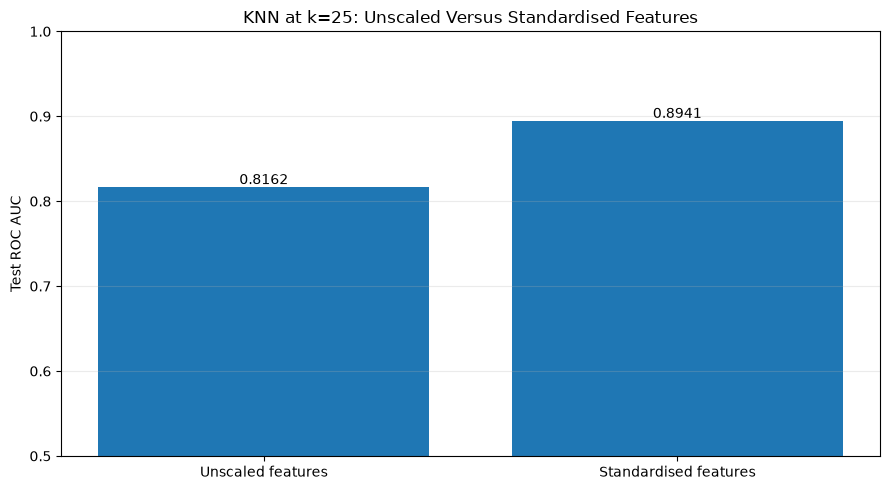

In [20]:
scaling_comparison_results = []

scaling_configurations = [
    ("Unscaled features", unscaled_preprocessor),
    ("Standardised features", scaled_preprocessor)
]

for label, preprocessor in scaling_configurations:
    pipeline = build_knn_pipeline(
        preprocessor=preprocessor,
        n_neighbors=25,
        metric="minkowski",
        p=2,
        weights="uniform"
    )

    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_train,
        y_data=y_train,
        n_splits=4
    )

    pipeline.fit(X_train, y_train)

    test_results, _, _ = evaluate_classifier(
        model_name=f"KNN (k=25) - {label}",
        model=pipeline,
        X_eval=X_test,
        y_eval=y_test
    )

    scaling_comparison_results.append({
        "Preprocessing": label,
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc,
        "Test AUC": test_results["ROC AUC"],
        "Test Average Precision": test_results["Average Precision"],
        "Default Recall": test_results["Default Recall"]
    })

scaling_comparison_df = pd.DataFrame(scaling_comparison_results)

print("Effect of Feature Scaling on KNN")
print(scaling_comparison_df.round(4).to_string(index=False))

scaling_gain = (
    scaling_comparison_df.loc[1, "Test AUC"]
    - scaling_comparison_df.loc[0, "Test AUC"]
)

print(
    f"\nStandardisation changes test AUC by {scaling_gain:+.4f}."
)

plt.figure(figsize=(9, 5))
plt.bar(
    scaling_comparison_df["Preprocessing"],
    scaling_comparison_df["Test AUC"]
)
for index, value in enumerate(scaling_comparison_df["Test AUC"]):
    plt.text(
        index,
        value + 0.004,
        f"{value:.4f}",
        ha="center"
    )
plt.ylabel("Test ROC AUC")
plt.ylim(0.5, 1.0)
plt.title("KNN at k=25: Unscaled Versus Standardised Features")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

**Choosing k with Cross-Validation**


Cross-Validated AUC by Number of Neighbours
 Neighbours  CV AUC Mean  CV AUC Std
          1       0.7767      0.0037
          3       0.8458      0.0028
          5       0.8631      0.0033
          9       0.8790      0.0016
         15       0.8857      0.0014
         21       0.8886      0.0014
         25       0.8893      0.0018
         31       0.8899      0.0012
         41       0.8903      0.0008
         51       0.8903      0.0009

Best k by cross-validated AUC: 51 (CV AUC = 0.8903)


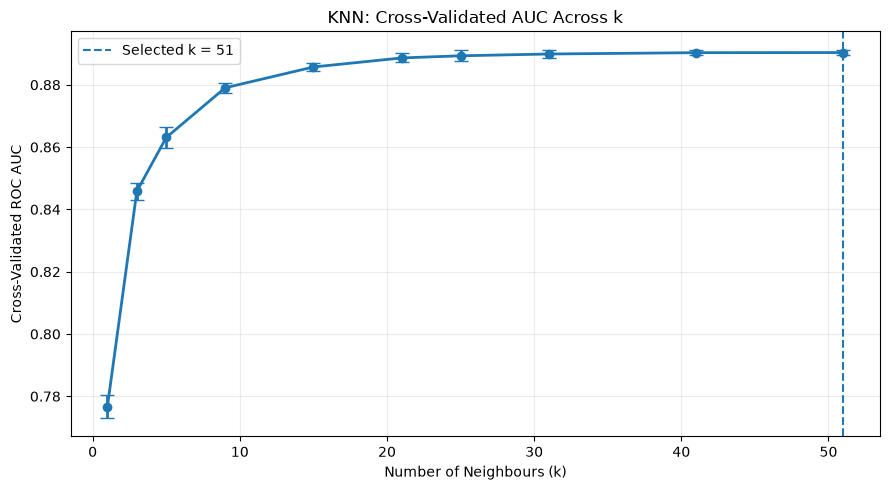

In [8]:
neighbour_values = [1, 3, 5, 9, 15, 21, 25, 31, 41, 51]

neighbour_results = []

for k in neighbour_values:
    pipeline = build_knn_pipeline(
        preprocessor=scaled_preprocessor,
        n_neighbors=k,
        metric="minkowski",
        p=2,
        weights="uniform"
    )

    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_train,
        y_data=y_train,
        n_splits=4
    )

    neighbour_results.append({
        "Neighbours": k,
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc
    })

neighbour_df = pd.DataFrame(neighbour_results)

print("Cross-Validated AUC by Number of Neighbours")
print(neighbour_df.round(4).to_string(index=False))

best_neighbour_row = neighbour_df.loc[
    neighbour_df["CV AUC Mean"].idxmax()
]

best_k = int(best_neighbour_row["Neighbours"])

print(
    f"\nBest k by cross-validated AUC: {best_k} "
    f"(CV AUC = {best_neighbour_row['CV AUC Mean']:.4f})"
)

plt.figure(figsize=(9, 5))
plt.errorbar(
    neighbour_df["Neighbours"],
    neighbour_df["CV AUC Mean"],
    yerr=neighbour_df["CV AUC Std"],
    marker="o",
    capsize=5,
    linewidth=2
)
plt.axvline(
    best_k,
    linestyle="--",
    label=f"Selected k = {best_k}"
)
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Cross-Validated ROC AUC")
plt.title("KNN: Cross-Validated AUC Across k")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**The Overfitting Signature of Small k**


Training Versus Test AUC Across k
 Neighbours  Train AUC  Test AUC  Train Minus Test
          1     1.0000    0.7841            0.2159
          5     0.9635    0.8658            0.0977
         15     0.9354    0.8866            0.0488
         25     0.9238    0.8941            0.0297
         41     0.9140    0.8934            0.0206

The train-test gap at k=1: 0.2159
The train-test gap at the widest neighbourhood tested: 0.0206


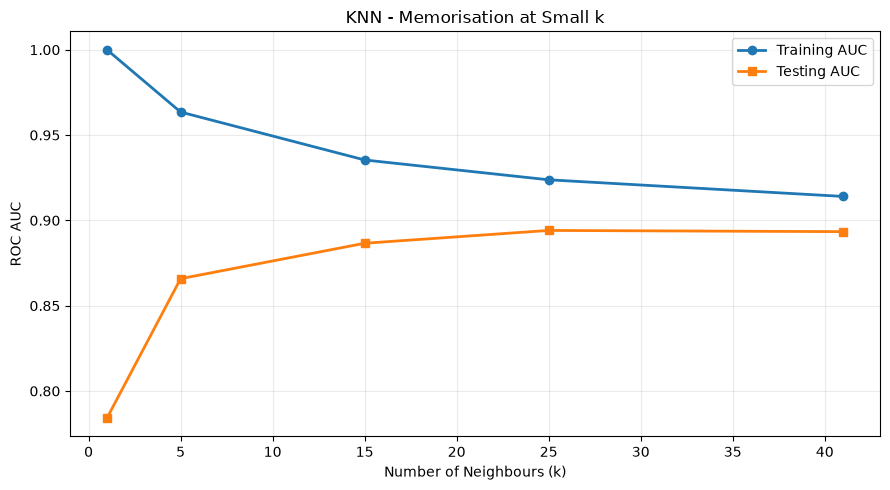

In [9]:
diagnostic_neighbour_values = [1, 5, 15, 25, 41]

diagnostic_results = []

for k in diagnostic_neighbour_values:
    pipeline = build_knn_pipeline(
        preprocessor=scaled_preprocessor,
        n_neighbors=k,
        metric="minkowski",
        p=2,
        weights="uniform"
    )

    pipeline.fit(X_train, y_train)

    train_probabilities = pipeline.predict_proba(X_train)[:, 1]
    test_probabilities = pipeline.predict_proba(X_test)[:, 1]

    diagnostic_results.append({
        "Neighbours": k,
        "Train AUC": roc_auc_score(y_train, train_probabilities),
        "Test AUC": roc_auc_score(y_test, test_probabilities)
    })

diagnostic_df = pd.DataFrame(diagnostic_results)
diagnostic_df["Train Minus Test"] = (
    diagnostic_df["Train AUC"]
    - diagnostic_df["Test AUC"]
)

print("Training Versus Test AUC Across k")
print(diagnostic_df.round(4).to_string(index=False))

print(
    "\nThe train-test gap at k=1:",
    f"{diagnostic_df.loc[0, 'Train Minus Test']:.4f}"
)
print(
    "The train-test gap at the widest neighbourhood tested:",
    f"{diagnostic_df.iloc[-1]['Train Minus Test']:.4f}"
)

plt.figure(figsize=(9, 5))
plt.plot(
    diagnostic_df["Neighbours"],
    diagnostic_df["Train AUC"],
    marker="o",
    linewidth=2,
    label="Training AUC"
)
plt.plot(
    diagnostic_df["Neighbours"],
    diagnostic_df["Test AUC"],
    marker="s",
    linewidth=2,
    label="Testing AUC"
)
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("ROC AUC")
plt.title("KNN - Memorisation at Small k")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Distance Metric Comparison**

- **Euclidean (Minkowski p=2)** takes the straight-line distance and, because differences are
  squared, is dominated by the feature on which two borrowers differ most.
- **Manhattan (Minkowski p=1)** sums absolute differences, treating a large gap on one feature as
  equivalent to several modest gaps spread across many. It is generally the more robust choice when
  the data contain outliers, which the income distribution here certainly does.
- **Minkowski p=3** pushes further in the euclidean direction, weighting the single largest
  disagreement even more heavily.
- **Chebyshev** takes this to its limit and considers *only* the largest single-feature difference,
  discarding all other information.
- **Cosine** ignores magnitude entirely and compares direction. Two borrowers with the same profile
  shape at different absolute scales are treated as neighbours.


Metric comparison subsample: 12,000 borrowers
Subsample default rate: 21.87%



Distance Metric Comparison at k=51
Distance Metric  CV AUC Mean  CV AUC Std
Manhattan (p=1)       0.8908      0.0065
Euclidean (p=2)       0.8860      0.0077
         Cosine       0.8843      0.0061
Minkowski (p=3)       0.8827      0.0070
      Chebyshev       0.8566      0.0064

Strongest metric: Manhattan (p=1)
Spread between best and worst metric: 0.0343 AUC


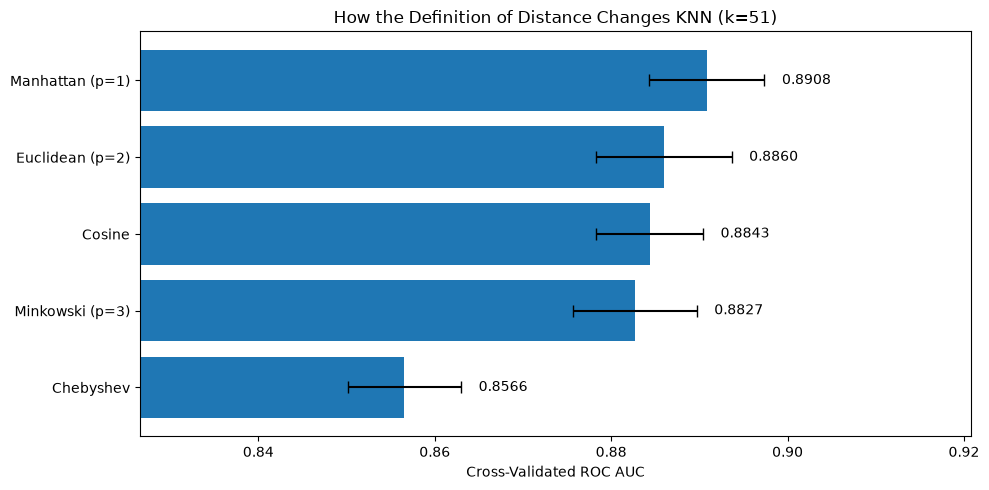

In [15]:
metric_subsample_size = 12000

subsample_indices, _ = train_test_split(
    np.arange(len(y_train)),
    train_size=metric_subsample_size,
    random_state=42,
    stratify=np.asarray(y_train)
)

X_metric = X_train.iloc[subsample_indices]
y_metric = y_train.iloc[subsample_indices]

print(f"Metric comparison subsample: {len(y_metric):,} borrowers")
print(f"Subsample default rate: {y_metric.mean() * 100:.2f}%")

distance_metric_settings = [
    {
        "Label": "Manhattan (p=1)",
        "Settings": {"metric": "minkowski", "p": 1}
    },
    {
        "Label": "Euclidean (p=2)",
        "Settings": {"metric": "minkowski", "p": 2}
    },
    {
        "Label": "Minkowski (p=3)",
        "Settings": {"metric": "minkowski", "p": 3}
    },
    {
        "Label": "Chebyshev",
        "Settings": {"metric": "chebyshev"}
    },
    {
        "Label": "Cosine",
        "Settings": {"metric": "cosine", "algorithm": "brute"}
    }
]

metric_results = []

for entry in distance_metric_settings:
    pipeline = build_knn_pipeline(
        preprocessor=scaled_preprocessor,
        n_neighbors=best_k,
        weights="uniform",
        **entry["Settings"]
    )

    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_metric,
        y_data=y_metric,
        n_splits=4
    )

    metric_results.append({
        "Distance Metric": entry["Label"],
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc
    })

metric_df = pd.DataFrame(metric_results).sort_values(
    "CV AUC Mean",
    ascending=False
).reset_index(drop=True)

print(f"\nDistance Metric Comparison at k={best_k}")
print(metric_df.round(4).to_string(index=False))

best_metric_label = metric_df.loc[0, "Distance Metric"]
metric_spread = (
    metric_df["CV AUC Mean"].max()
    - metric_df["CV AUC Mean"].min()
)

print(f"\nStrongest metric: {best_metric_label}")
print(f"Spread between best and worst metric: {metric_spread:.4f} AUC")

metric_order = metric_df.sort_values("CV AUC Mean")

plt.figure(figsize=(10, 5))
plt.barh(
    metric_order["Distance Metric"],
    metric_order["CV AUC Mean"],
    xerr=metric_order["CV AUC Std"],
    capsize=4
)


for index, (value, std) in enumerate(zip(metric_order["CV AUC Mean"], metric_order["CV AUC Std"])):
    plt.text(
        value + std + 0.002,
        index,
        f"{value:.4f}",
        va="center"
    )

plt.xlabel("Cross-Validated ROC AUC")
plt.title(f"How the Definition of Distance Changes KNN (k={best_k})")
plt.xlim(
    metric_order["CV AUC Mean"].min() - 0.03,
    metric_order["CV AUC Mean"].max() + 0.03
)
plt.tight_layout()
plt.show()

**Uniform Versus Distance Weighting**


Neighbour Weighting Comparison
 Neighbours Weighting  CV AUC Mean  CV AUC Std
         15   uniform       0.8857      0.0014
         15  distance       0.8897      0.0015
         25   uniform       0.8893      0.0018
         25  distance       0.8939      0.0016
         41   uniform       0.8903      0.0008
         41  distance       0.8954      0.0004

Distance Weighting Advantage by k
Weighting   distance  uniform  Distance Advantage
Neighbours                                       
15            0.8897   0.8857              0.0040
25            0.8939   0.8893              0.0046
41            0.8954   0.8903              0.0051


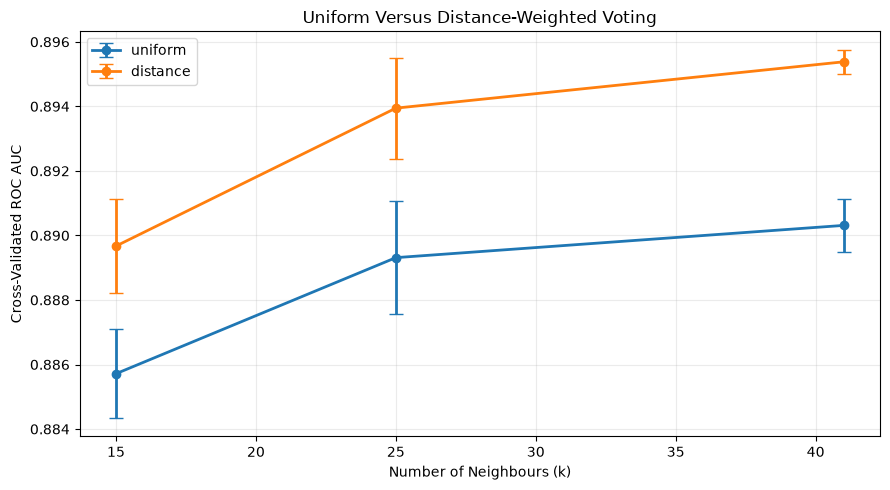

In [11]:
weighting_neighbour_values = [15, 25, 41]

weighting_results = []

for k in weighting_neighbour_values:
    for weighting in ["uniform", "distance"]:
        pipeline = build_knn_pipeline(
            preprocessor=scaled_preprocessor,
            n_neighbors=k,
            metric="minkowski",
            p=2,
            weights=weighting
        )

        mean_auc, std_auc = cross_validated_scores(
            pipeline=pipeline,
            X_data=X_train,
            y_data=y_train,
            n_splits=4
        )

        weighting_results.append({
            "Neighbours": k,
            "Weighting": weighting,
            "CV AUC Mean": mean_auc,
            "CV AUC Std": std_auc
        })

weighting_df = pd.DataFrame(weighting_results)

print("Neighbour Weighting Comparison")
print(weighting_df.round(4).to_string(index=False))

weighting_pivot = weighting_df.pivot(
    index="Neighbours",
    columns="Weighting",
    values="CV AUC Mean"
)

weighting_pivot["Distance Advantage"] = (
    weighting_pivot["distance"]
    - weighting_pivot["uniform"]
)

print("\nDistance Weighting Advantage by k")
print(weighting_pivot.round(4).to_string())

plt.figure(figsize=(9, 5))
for weighting in ["uniform", "distance"]:
    subset = weighting_df[weighting_df["Weighting"] == weighting]
    plt.errorbar(
        subset["Neighbours"],
        subset["CV AUC Mean"],
        yerr=subset["CV AUC Std"],
        marker="o",
        capsize=5,
        linewidth=2,
        label=weighting
    )
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Cross-Validated ROC AUC")
plt.title("Uniform Versus Distance-Weighted Voting")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Dimensionality and the Encoded Feature Space**


In [31]:
feature_space_configurations = [
    (
        "Numeric only (6 features)",
        numeric_only_preprocessor
    ),
    (
        f"Numeric plus one-hot ({len(feature_names)} features)",
        scaled_preprocessor
    )
]
feature_space_results = []
for label, preprocessor in feature_space_configurations:
    pipeline = build_knn_pipeline(
        preprocessor=preprocessor,
        n_neighbors=best_k,
        metric="minkowski",
        p=2,
        weights="distance"
    )
    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_train,
        y_data=y_train,
        n_splits=4
    )
    pipeline.fit(X_train, y_train)
    test_results, _, _ = evaluate_classifier(
        model_name=f"KNN - {label}",
        model=pipeline,
        X_eval=X_test,
        y_eval=y_test
    )
    feature_space_results.append({
        "Feature Space": label,
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc,
        "Test AUC": test_results["ROC AUC"],
        "Test Average Precision": test_results["Average Precision"]
    })
feature_space_df = pd.DataFrame(feature_space_results)
print("Effect of the Encoded Feature Space on KNN")
print(feature_space_df.round(4).to_string(index=False))
feature_space_difference = (
    feature_space_df.loc[1, "CV AUC Mean"]
    - feature_space_df.loc[0, "CV AUC Mean"]
)
print(
    "\nAdding the one-hot categoricals changes CV AUC by",
    f"{feature_space_difference:+.4f}."
)
if feature_space_difference > 0.002:
    selected_preprocessor = scaled_preprocessor
    selected_space_label = "numeric plus one-hot"
    print(
        " The categorical indicators contribute usable signal "
        "to the distance metric and are retained."
    )
elif feature_space_difference < -0.002:
    selected_preprocessor = numeric_only_preprocessor
    selected_space_label = "numeric only"
    print(
        "The categorical indicators dilute the distance metric. "
        "The numeric-only space is the better representation for KNN."
    )
else:
    selected_preprocessor = scaled_preprocessor
    selected_space_label = "numeric plus one-hot"
    print(
        "The two feature spaces are effectively tied, so the "
        "fuller representation is retained for comparability with the "
        "tree-based models of Weeks 6 and 9."
    )
print(f"Feature space carried into tuning: {selected_space_label}")



Effect of the Encoded Feature Space on KNN
                     Feature Space  CV AUC Mean  CV AUC Std  Test AUC  Test Average Precision
         Numeric only (6 features)       0.8817      0.0012    0.8884                  0.7588
Numeric plus one-hot (25 features)       0.8955      0.0003    0.9003                  0.8199

Adding the one-hot categoricals changes CV AUC by +0.0138.
 The categorical indicators contribute usable signal to the distance metric and are retained.
Feature space carried into tuning: numeric plus one-hot


In [33]:
feature_space_configurations = [
    (
        "Numeric only (6 features)",
        numeric_only_preprocessor
    ),
    (
        f"Numeric plus one-hot ({len(feature_names)} features)",
        scaled_preprocessor
    )
]

feature_space_results = []

for label, preprocessor in feature_space_configurations:
    pipeline = build_knn_pipeline(
        preprocessor=preprocessor,
        n_neighbors=best_k,
        metric="minkowski",
        p=2,
        weights="distance"
    )

    mean_auc, std_auc = cross_validated_scores(
        pipeline=pipeline,
        X_data=X_train,
        y_data=y_train,
        n_splits=4
    )

    pipeline.fit(X_train, y_train)

    test_results, _, _ = evaluate_classifier(
        model_name=f"KNN - {label}",
        model=pipeline,
        X_eval=X_test,
        y_eval=y_test
    )

    feature_space_results.append({
        "Feature Space": label,
        "CV AUC Mean": mean_auc,
        "CV AUC Std": std_auc,
        "Test AUC": test_results["ROC AUC"],
        "Test Average Precision": test_results["Average Precision"]
    })

feature_space_df = pd.DataFrame(feature_space_results)

print("Effect of the Encoded Feature Space on KNN")
print(feature_space_df.round(4).to_string(index=False))

feature_space_difference = (
    feature_space_df.loc[1, "CV AUC Mean"]
    - feature_space_df.loc[0, "CV AUC Mean"]
)

print(
    "\nAdding the one-hot categoricals changes CV AUC by",
    f"{feature_space_difference:+.4f}."
)

if feature_space_difference > 0.002:
    selected_preprocessor = scaled_preprocessor
    selected_space_label = "numeric plus one-hot"
    print(
        "The categorical indicators contribute usable signal "
        "to the distance metric and are retained."
    )
elif feature_space_difference < -0.002:
    selected_preprocessor = numeric_only_preprocessor
    selected_space_label = "numeric only"
    print(
        "The categorical indicators dilute the distance metric. "
        "The numeric-only space is the better representation for KNN."
    )
else:
    selected_preprocessor = scaled_preprocessor
    selected_space_label = "numeric plus one-hot"
    print(
        "Possibly the two feature spaces are effectively tied, so the "
        "fuller representation is retained for comparability with the "
        "tree-based models of Weeks 6 and 9."
    )

print(f"Feature space carried into tuning: {selected_space_label}")

Effect of the Encoded Feature Space on KNN
                     Feature Space  CV AUC Mean  CV AUC Std  Test AUC  Test Average Precision
         Numeric only (6 features)       0.8817      0.0012    0.8884                  0.7588
Numeric plus one-hot (25 features)       0.8955      0.0003    0.9003                  0.8199

Adding the one-hot categoricals changes CV AUC by +0.0138.
The categorical indicators contribute usable signal to the distance metric and are retained.
Feature space carried into tuning: numeric plus one-hot


**Hyperparameter Tuning with Stratified Cross-Validation**


In [14]:
parameter_grid = [
    {
        "knn__n_neighbors": [15, 25, 35],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["minkowski"],
        "knn__p": [1, 2]
    },
    {
        "knn__n_neighbors": [15, 25, 35],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["cosine"],
        "knn__algorithm": ["brute"]
    }
]

base_search_pipeline = build_knn_pipeline(
    preprocessor=selected_preprocessor
)

stratified_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

knn_search = GridSearchCV(
    estimator=base_search_pipeline,
    param_grid=parameter_grid,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    refit="roc_auc",
    cv=stratified_cv,
    n_jobs=1, # CHANGED: Set to 1 to prevent Out of Memory (OOM) crashes
    verbose=1,
    return_train_score=True
)

# If memory still crashes even with n_jobs=1, replace X_train/y_train with X_metric/y_metric below
knn_search.fit(X_train, y_train) 

print("\nBest Parameters")
print(knn_search.best_params_)
print(f"\nBest Cross-Validated AUC: {knn_search.best_score_:.4f}")

search_results = pd.DataFrame(knn_search.cv_results_)

search_summary = search_results[
    [
        "rank_test_roc_auc",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "mean_test_average_precision",
        "mean_train_roc_auc",
        "params"
    ]
].sort_values("rank_test_roc_auc").head(10)

print("\nTop Hyperparameter Combinations")
print(search_summary.round(4).to_string(index=False))

best_row = search_results.loc[
    search_results["rank_test_roc_auc"].idxmin()
]

print(
    "\nTrain minus validation AUC for the selected model:",
    f"{best_row['mean_train_roc_auc'] - best_row['mean_test_roc_auc']:+.4f}"
)

Fitting 4 folds for each of 18 candidates, totalling 72 fits

Best Parameters
{'knn__metric': 'minkowski', 'knn__n_neighbors': 35, 'knn__p': 1, 'knn__weights': 'distance'}

Best Cross-Validated AUC: 0.9017

Top Hyperparameter Combinations
 rank_test_roc_auc  mean_test_roc_auc  std_test_roc_auc  mean_test_average_precision  mean_train_roc_auc                                                                                                   params
                 1             0.9017            0.0014                       0.8258              1.0000            {'knn__metric': 'minkowski', 'knn__n_neighbors': 35, 'knn__p': 1, 'knn__weights': 'distance'}
                 2             0.9002            0.0013                       0.8271              1.0000            {'knn__metric': 'minkowski', 'knn__n_neighbors': 25, 'knn__p': 1, 'knn__weights': 'distance'}
                 3             0.8968            0.0018                       0.8065              0.9199             {'knn__metric'

**Evaluate the Tuned KNN Model**


Tuned KNN
----------------------------------------
Accuracy              : 0.9067
Balanced Accuracy     : 0.8019
ROC AUC               : 0.9056
Average Precision     : 0.8345
Default Precision     : 0.9357
Default Recall        : 0.6157
Default F1            : 0.7427

Classification Report
              precision    recall  f1-score   support

      Repaid       0.90      0.99      0.94      5064
     Default       0.94      0.62      0.74      1418

    accuracy                           0.91      6482
   macro avg       0.92      0.80      0.84      6482
weighted avg       0.91      0.91      0.90      6482



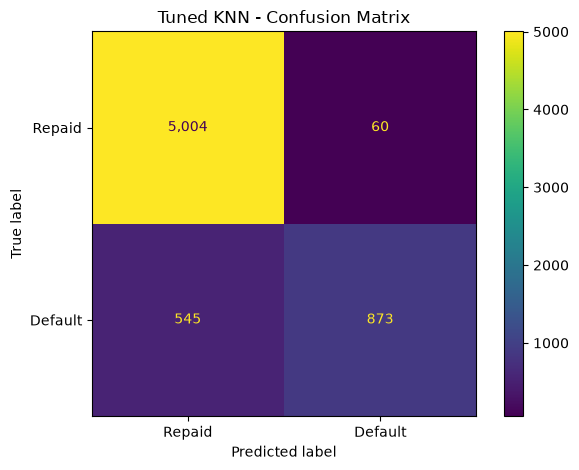

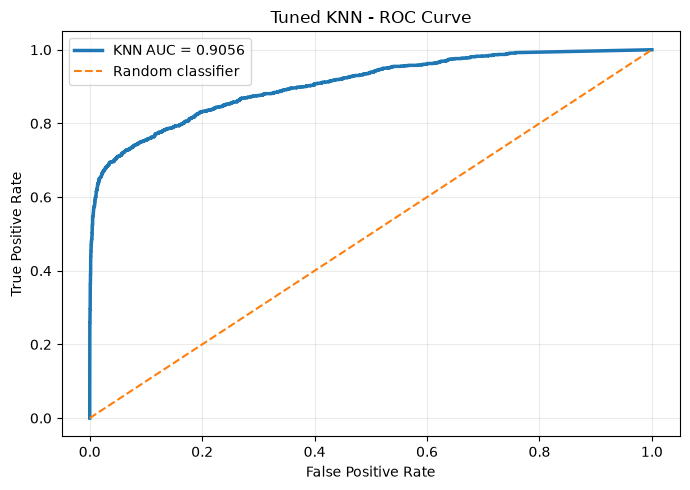

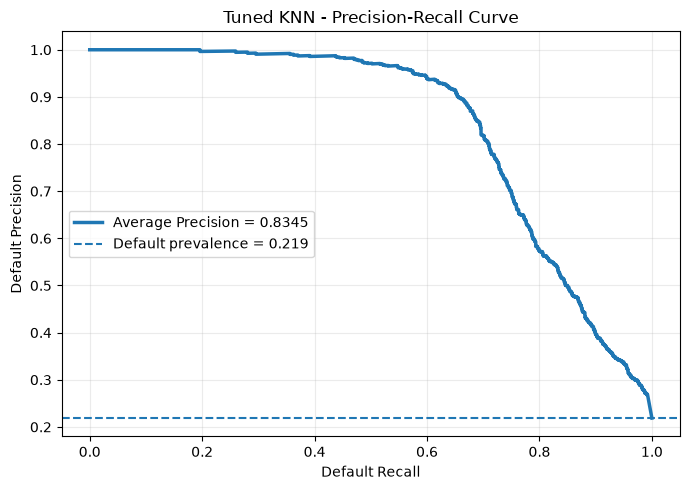

In [21]:
best_knn = knn_search.best_estimator_

tuned_results, tuned_probabilities, tuned_predictions = evaluate_classifier(
    model_name="Tuned KNN",
    model=best_knn,
    X_eval=X_test,
    y_eval=y_test,
    threshold=0.50
)

print("Tuned KNN")
print("-" * 40)

for metric, value in tuned_results.items():
    if metric not in ["Model", "Threshold"]:
        print(f"{metric:<22}: {value:.4f}")

print("\nClassification Report")
print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=["Repaid", "Default"]
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    display_labels=["Repaid", "Default"],
    values_format=",d"
)
plt.title("Tuned KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    tuned_probabilities
)

plt.figure(figsize=(7, 5))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2.5,
    label=f"KNN AUC = {tuned_results['ROC AUC']:.4f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned KNN - ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

test_precision_curve, test_recall_curve, _ = precision_recall_curve(
    y_test,
    tuned_probabilities
)

plt.figure(figsize=(7, 5))
plt.plot(
    test_recall_curve,
    test_precision_curve,
    linewidth=2.5,
    label=(
        "Average Precision = "
        f"{tuned_results['Average Precision']:.4f}"
    )
)
plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Default prevalence = {y_test.mean():.3f}"
)
plt.xlabel("Default Recall")
plt.ylabel("Default Precision")
plt.title("Tuned KNN - Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Selecting a Classification Threshold on Validation Data**


Distinct probability values available from this neighbourhood vote: 4217

Validation-selected threshold: 0.4015
Validation F1 at selected threshold: 0.7458

Threshold Comparison
                           Model  Threshold  Accuracy  Balanced Accuracy  Default Precision  Default Recall  Default F1
                       Tuned KNN     0.5000    0.9067             0.8019             0.9357          0.6157      0.7427
Tuned KNN - Validation Threshold     0.4015    0.9073             0.8244             0.8704          0.6770      0.7616

Classification Report at Validation-Selected Threshold
              precision    recall  f1-score   support

      Repaid       0.91      0.97      0.94      5064
     Default       0.87      0.68      0.76      1418

    accuracy                           0.91      6482
   macro avg       0.89      0.82      0.85      6482
weighted avg       0.91      0.91      0.90      6482



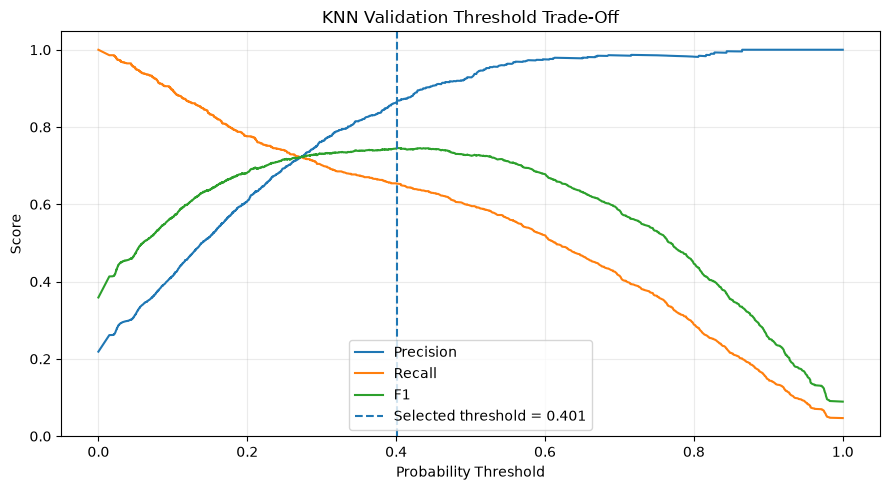

In [22]:
y_train_array = np.asarray(y_train)
all_training_indices = np.arange(len(y_train_array))

threshold_fit_indices, threshold_validation_indices = train_test_split(
    all_training_indices,
    test_size=0.20,
    random_state=42,
    stratify=y_train_array
)

threshold_model = clone(best_knn)

threshold_model.fit(
    X_train.iloc[threshold_fit_indices],
    y_train_array[threshold_fit_indices]
)

validation_probabilities = threshold_model.predict_proba(
    X_train.iloc[threshold_validation_indices]
)[:, 1]

print(
    "Distinct probability values available from this neighbourhood vote:",
    f"{len(np.unique(validation_probabilities))}"
)

validation_precision, validation_recall, validation_thresholds = (
    precision_recall_curve(
        y_train_array[threshold_validation_indices],
        validation_probabilities
    )
)

validation_f1 = (
    2
    * validation_precision[:-1]
    * validation_recall[:-1]
    / (
        validation_precision[:-1]
        + validation_recall[:-1]
        + 1e-12
    )
)

best_threshold_index = int(np.nanargmax(validation_f1))
selected_threshold = float(
    validation_thresholds[best_threshold_index]
)

print(f"\nValidation-selected threshold: {selected_threshold:.4f}")
print(
    "Validation F1 at selected threshold:",
    f"{validation_f1[best_threshold_index]:.4f}"
)

threshold_results, _, threshold_predictions = evaluate_classifier(
    model_name="Tuned KNN - Validation Threshold",
    model=best_knn,
    X_eval=X_test,
    y_eval=y_test,
    threshold=selected_threshold
)

threshold_comparison = pd.DataFrame(
    [tuned_results, threshold_results]
)

print("\nThreshold Comparison")
print(
    threshold_comparison[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Balanced Accuracy",
            "Default Precision",
            "Default Recall",
            "Default F1"
        ]
    ].round(4).to_string(index=False)
)

print("\nClassification Report at Validation-Selected Threshold")
print(
    classification_report(
        y_test,
        threshold_predictions,
        target_names=["Repaid", "Default"]
    )
)

plt.figure(figsize=(9, 5))
plt.plot(
    validation_thresholds,
    validation_precision[:-1],
    label="Precision"
)
plt.plot(
    validation_thresholds,
    validation_recall[:-1],
    label="Recall"
)
plt.plot(
    validation_thresholds,
    validation_f1,
    label="F1"
)
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.3f}"
)
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("KNN Validation Threshold Trade-Off")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Permutation Importance**


KNN Permutation Importance
                  Feature  Permutation Importance  Importance Std
      loan_percent_income                 0.11865         0.00302
    person_home_ownership                 0.05573         0.00341
               loan_grade                 0.05153         0.00133
              loan_intent                 0.03518         0.00232
            loan_int_rate                 0.03083         0.00114
            person_income                 0.02255         0.00142
                loan_amnt                 0.01340         0.00110
        person_emp_length                 0.00822         0.00178
               person_age                 0.00561         0.00209
cb_person_default_on_file                -0.00141         0.00047


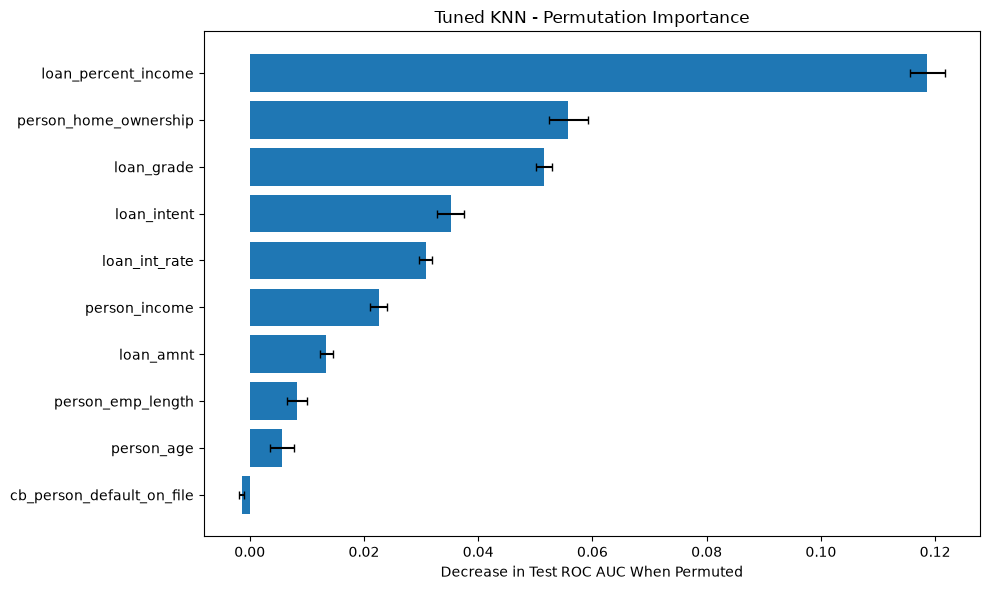

In [23]:
permutation_results = permutation_importance(
    estimator=best_knn,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation Importance": permutation_results.importances_mean,
    "Importance Std": permutation_results.importances_std
}).sort_values(
    "Permutation Importance",
    ascending=False
)

print("KNN Permutation Importance")
print(permutation_importance_df.round(5).to_string(index=False))

top_permutation = permutation_importance_df.sort_values(
    "Permutation Importance"
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_permutation["Feature"],
    top_permutation["Permutation Importance"],
    xerr=top_permutation["Importance Std"],
    capsize=3
)
plt.xlabel("Decrease in Test ROC AUC When Permuted")
plt.title("Tuned KNN - Permutation Importance")
plt.tight_layout()
plt.show()

**Benchmark Against Weeks 6 and 9**


Week 8 Model Leaderboard
                                   Model  ROC AUC  Average Precision  Accuracy  Balanced Accuracy  Default Precision  Default Recall  Default F1
Gradient Boosting - Week 9 Specification   0.9538             0.9113    0.9148             0.8813             0.7958          0.8216      0.8085
    Random Forest - Week 6 Specification   0.9345             0.8875    0.9185             0.8659             0.8423          0.7722      0.8057
        Tuned KNN - Validation Threshold   0.9056             0.8345    0.9073             0.8244             0.8704          0.6770      0.7616
                               Tuned KNN   0.9056             0.8345    0.9067             0.8019             0.9357          0.6157      0.7427


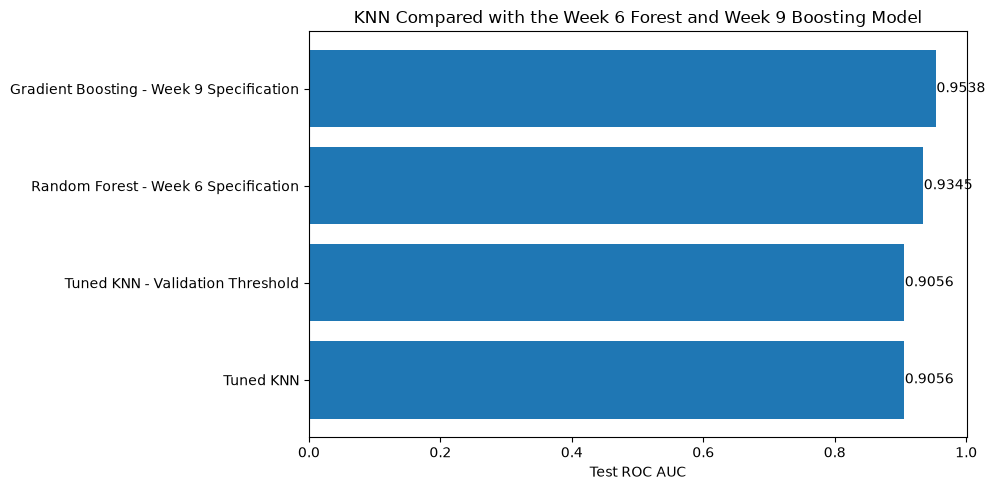

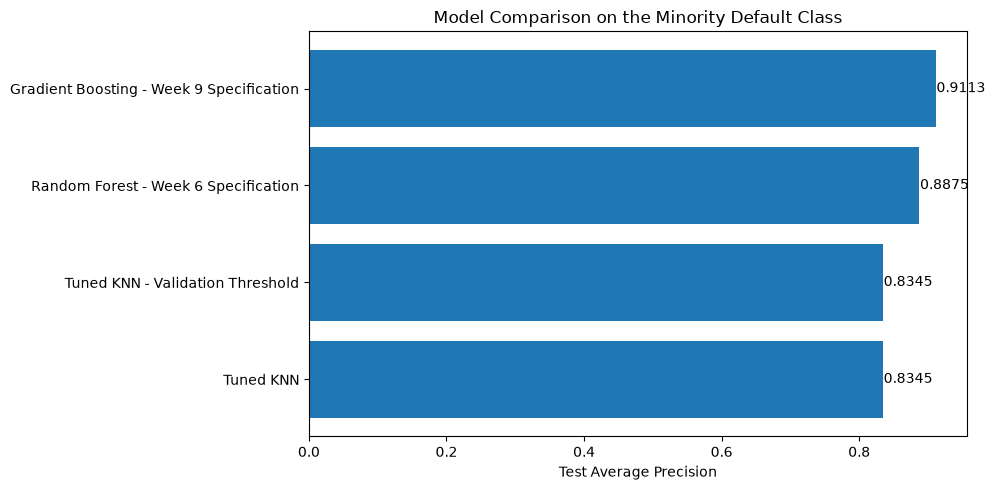


Tuned KNN minus Week 9 Gradient Boosting AUC: -0.0481
Tuned KNN minus Week 6 Random Forest AUC: -0.0289
Gradient boosting retains the stronger risk ranking. KNN recovers much of the available signal from local similarity alone, but the sequential ensemble captures feature interactions that neighbourhood voting cannot express.

 KNN carries no trained parameters, so the entire training set must be retained and searched at prediction time. For a lender scoring applications in real time, that operational cost is a genuine consideration alongside AUC.


In [34]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

random_forest.fit(
    X_train_enc,
    y_train
)

rf_results, rf_probabilities, rf_predictions = evaluate_classifier(
    model_name="Random Forest - Week 6 Specification",
    model=random_forest,
    X_eval=X_test_enc,
    y_eval=y_test,
    threshold=0.50
)

gradient_boosting = GradientBoostingClassifier(
    subsample=0.85,
    n_estimators=300,
    min_samples_leaf=3,
    max_features=None,
    max_depth=4,
    learning_rate=0.10,
    random_state=42
)

gradient_boosting.fit(
    X_train_enc,
    y_train,
    sample_weight=train_weights
)

gb_results, gb_probabilities, gb_predictions = evaluate_classifier(
    model_name="Gradient Boosting - Week 9 Specification",
    model=gradient_boosting,
    X_eval=X_test_enc,
    y_eval=y_test,
    threshold=0.50
)

model_comparison = pd.DataFrame([
    tuned_results,
    threshold_results,
    rf_results,
    gb_results
]).sort_values(
    "ROC AUC",
    ascending=False
).reset_index(drop=True)

comparison_columns = [
    "Model",
    "ROC AUC",
    "Average Precision",
    "Accuracy",
    "Balanced Accuracy",
    "Default Precision",
    "Default Recall",
    "Default F1"
]

print("Week 8 Model Leaderboard")
print(
    model_comparison[comparison_columns]
    .round(4)
    .to_string(index=False)
)

auc_order = model_comparison.sort_values("ROC AUC")

plt.figure(figsize=(10, 5))
plt.barh(
    auc_order["Model"],
    auc_order["ROC AUC"]
)
for index, value in enumerate(auc_order["ROC AUC"]):
    plt.text(
        value + 0.001,
        index,
        f"{value:.4f}",
        va="center"
    )
plt.xlabel("Test ROC AUC")
plt.title("KNN Compared with the Week 6 Forest and Week 9 Boosting Model")
plt.tight_layout()
plt.show()

ap_order = model_comparison.sort_values("Average Precision")

plt.figure(figsize=(10, 5))
plt.barh(
    ap_order["Model"],
    ap_order["Average Precision"]
)
for index, value in enumerate(ap_order["Average Precision"]):
    plt.text(
        value + 0.001,
        index,
        f"{value:.4f}",
        va="center"
    )
plt.xlabel("Test Average Precision")
plt.title("Model Comparison on the Minority Default Class")
plt.tight_layout()
plt.show()

knn_gb_difference = (
    tuned_results["ROC AUC"]
    - gb_results["ROC AUC"]
)

knn_rf_difference = (
    tuned_results["ROC AUC"]
    - rf_results["ROC AUC"]
)

print(
    f"\nTuned KNN minus Week 9 Gradient Boosting AUC: {knn_gb_difference:+.4f}"
)
print(
    f"Tuned KNN minus Week 6 Random Forest AUC: {knn_rf_difference:+.4f}"
)

if knn_gb_difference > 0.002:
    print(
        "A purely local, memory-based method outranks the "
        "boosted ensemble on this test set, which would be a notable result "
        "for a model that fits no global structure whatsoever."
    )
elif knn_gb_difference < -0.002:
    print(
        "Gradient boosting retains the stronger risk ranking. "
        "KNN recovers much of the available signal from local similarity "
        "alone, but the sequential ensemble captures feature interactions "
        "that neighbourhood voting cannot express."
    )
else:
    print(
        "KNN and gradient boosting rank borrower risk almost "
        "identically, so prediction speed, interpretability, and the cost "
        "of storing the training set become the deciding criteria."
    )

print(
    "\n KNN carries no trained parameters, so the entire training "
    "set must be retained and searched at prediction time. For a lender "
    "scoring applications in real time, that operational cost is a genuine "
    "consideration alongside AUC."
)